In [ ]:
# ============================================
# GLOBAL SUPERSTORE DATA ANALYSIS
# Step 1: Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving SuperStoreOrders - SuperStoreOrders.csv to SuperStoreOrders - SuperStoreOrders.csv


In [4]:
import os

print(os.listdir('/content'))

['.config', 'SuperStoreOrders - SuperStoreOrders.csv', 'sample_data']


In [5]:
# Load the dataset

df = pd.read_csv('SuperStoreOrders - SuperStoreOrders.csv')

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [6]:
# First 5 rows

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [7]:
# Dataset information

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (51290, 21)

Column names:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id    

In [8]:
# ============================================
# DATA PRE-PROCESSING
# 1. Check Missing Values
# ============================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [9]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
# ============================================
# 2. CONVERT DATE COLUMNS
# ============================================

df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True,
    errors='coerce'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    dayfirst=True,
    errors='coerce'
)

print("Date columns converted successfully!")

print(df[['order_date', 'ship_date']].head())

Date columns converted successfully!
  order_date  ship_date
0 2011-01-01 2011-01-06
1 2011-01-01 2011-01-08
2 2011-01-01 2011-01-05
3 2011-01-01 2011-01-05
4 2011-01-01 2011-01-08


In [11]:
# ============================================
# 3. CONVERT SALES TO NUMERIC
# ============================================

df['sales'] = pd.to_numeric(
    df['sales'],
    errors='coerce'
)

print("Sales column converted successfully!")

print(df['sales'].dtype)

Sales column converted successfully!
float64


In [12]:
# ============================================
# 4. VERIFY DATA TYPES
# ============================================

print(df.dtypes)

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object


In [14]:
# ============================================
# 5. CREATE NEW COLUMNS
# ============================================

# Shipping duration in days
df['shipping_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

# Year and month
df['order_month'] = df['order_date'].dt.month

df['order_month_name'] = (
    df['order_date'].dt.month_name()
)

# Quarter
df['order_quarter'] = (
    df['order_date'].dt.quarter
)

print("New columns created successfully!")

print(df[
    [
        'order_date',
        'ship_date',
        'shipping_days',
        'order_month',
        'order_quarter'
    ]
].head())

New columns created successfully!
  order_date  ship_date  shipping_days  order_month  order_quarter
0 2011-01-01 2011-01-06              5            1              1
1 2011-01-01 2011-01-08              7            1              1
2 2011-01-01 2011-01-05              4            1              1
3 2011-01-01 2011-01-05              4            1              1
4 2011-01-01 2011-01-08              7            1              1


In [15]:
# ============================================
# FINAL DATA QUALITY CHECK
# ============================================

print("Dataset shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nShipping days summary:")
print(df['shipping_days'].describe())

print("\nYear range:")
print(
    df['order_date'].dt.year.min(),
    "to",
    df['order_date'].dt.year.max()
)

Dataset shape: (51290, 25)

Missing values after cleaning:
order_id               0
order_date             0
ship_date              0
ship_mode              0
customer_name          0
segment                0
state                  0
country                0
market                 0
region                 0
product_id             0
category               0
sub_category           0
product_name           0
sales               2630
quantity               0
discount               0
profit                 0
shipping_cost          0
order_priority         0
year                   0
shipping_days          0
order_month            0
order_month_name       0
order_quarter          0
dtype: int64

Shipping days summary:
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

Year range:
2011 to 2014


In [16]:
# Check invalid shipping days

print(
    "Negative shipping days:",
    (df['shipping_days'] < 0).sum()
)

print(
    "Missing order dates:",
    df['order_date'].isna().sum()
)

print(
    "Missing ship dates:",
    df['ship_date'].isna().sum()
)

Negative shipping days: 0
Missing order dates: 0
Missing ship dates: 0


In [17]:
# ============================================
# BUSINESS KPIs
# ============================================

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_quantity = df['quantity'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_name'].nunique()

profit_margin = (total_profit / total_sales) * 100
average_shipping_days = df['shipping_days'].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Shipping Days:", round(average_shipping_days, 2))

Total Sales: 7835128.0
Total Profit: 1469034.82
Total Quantity: 178312
Total Orders: 25035
Total Customers: 795
Profit Margin: 18.75 %
Average Shipping Days: 3.97


In [18]:
# ============================================
# CHECK MISSING SALES VALUES
# ============================================

print("Missing sales values:", df['sales'].isna().sum())

print("\nRows with missing sales:")
display(df[df['sales'].isna()].head(10))

Missing sales values: 2630

Rows with missing sales:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,order_month,order_month_name,order_quarter
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",NaN,6,0.0,609.8400,109.13,Medium,2011,5,1,January,1
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",NaN,8,0.0,999.3600,191.20,Medium,2011,4,1,January,1
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,NaN,9,0.0,746.4078,258.99,High,2011,4,1,January,1
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",NaN,6,0.0,49.5000,349.87,High,2011,5,1,January,1
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",NaN,7,0.0,260.8200,275.52,Medium,2011,4,1,January,1
100,IN-2011-61302,2011-01-10,2011-01-11,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",NaN,5,0.1,511.0950,665.27,Medium,2011,1,1,January,1
125,ES-2011-5158390,2011-01-11,2011-01-11,Same Day,Roy Collins,Consumer,England,United Kingdom,EU,North,FUR-CH-10004255,Furniture,Chairs,"SAFCO Executive Leather Armchair, Red",NaN,3,0.0,13.7700,178.98,Medium,2011,0,1,January,1
126,US-2011-163874,2011-01-11,2011-01-12,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,OFF-ST-10003741,Office Supplies,Storage,"Smead Lockers, Blue",NaN,10,0.0,238.0000,103.84,Medium,2011,1,1,January,1
163,EG-2011-4270,2011-01-13,2011-01-18,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,TEC-HP -10001574,Technology,Copiers,"HP Fax Machine, Laser",NaN,4,0.0,479.8800,55.62,Medium,2011,5,1,January,1
173,CA-2011-157147,2011-01-14,2011-01-19,Standard Class,Brian Dahlen,Consumer,California,United States,US,West,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,NaN,5,0.0,238.6530,187.65,High,2011,5,1,January,1


In [19]:
# ============================================
# CREATE CLEAN DATASET FOR ANALYSIS
# ============================================

df_clean = df.dropna(subset=['sales']).copy()

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)
print("Removed rows:", len(df) - len(df_clean))

print("\nMissing values in sales after cleaning:",
      df_clean['sales'].isna().sum())

print("\nMissing values in all columns:")
print(df_clean.isnull().sum())

Original dataset shape: (51290, 25)
Clean dataset shape: (48660, 25)
Removed rows: 2630

Missing values in sales after cleaning: 0

Missing values in all columns:
order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_name       0
segment             0
state               0
country             0
market              0
region              0
product_id          0
category            0
sub_category        0
product_name        0
sales               0
quantity            0
discount            0
profit              0
shipping_cost       0
order_priority      0
year                0
shipping_days       0
order_month         0
order_month_name    0
order_quarter       0
dtype: int64


In [20]:
df_clean

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,order_month,order_month_name,order_quarter
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.1400,35.46,Medium,2011,5,1,January,1
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.0360,9.72,Medium,2011,7,1,January,1
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.6400,8.17,High,2011,4,1,January,1
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.0550,4.82,High,2011,4,1,January,1
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.7700,4.70,Medium,2011,7,1,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-01-04,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14.0,2,0.2,4.5188,0.89,Medium,2014,4,12,December,4
51286,MO-2014-2560,2014-12-31,2015-01-05,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4.0,1,0.0,0.4200,0.49,Medium,2014,5,12,December,4
51287,MX-2014-110527,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26.0,3,0.0,12.3600,0.35,Medium,2014,2,12,December,4
51288,MX-2014-114783,2014-12-31,2015-01-06,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7.0,1,0.0,0.5600,0.20,Medium,2014,6,12,December,4


In [21]:
# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# NUMERICAL SUMMARY
# ============================================

df_clean[['sales', 'quantity', 'discount',
          'profit', 'shipping_cost',
          'shipping_days']].describe()

,sales,quantity,discount,profit,shipping_cost,shipping_days
count,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000,48660.000000
mean,161.017838,3.350658,0.145722,14.688249,17.593780,3.972154
std,201.092519,2.198216,0.215066,86.825672,28.559365,1.727526
min,0.000000,1.000000,0.000000,-1924.542000,0.000000,0.000000
25%,29.000000,2.000000,0.000000,0.000000,2.450000,3.000000
50%,77.000000,3.000000,0.000000,8.460000,7.030000,4.000000
75%,208.000000,4.000000,0.200000,31.154400,20.152500,5.000000
max,999.000000,14.000000,0.850000,486.600000,427.100000,7.000000


In [22]:
# ============================================
# CHECK IMPORTANT VALUES
# ============================================

print("Zero-sales rows:",
      (df_clean['sales'] == 0).sum())

print("Loss-making rows:",
      (df_clean['profit'] < 0).sum())

print("Profitable rows:",
      (df_clean['profit'] > 0).sum())

print("Zero-profit rows:",
      (df_clean['profit'] == 0).sum())

print("\nUnique categories:",
      df_clean['category'].nunique())

print("Unique sub-categories:",
      df_clean['sub_category'].nunique())

print("Unique regions:",
      df_clean['region'].nunique())

print("Unique markets:",
      df_clean['market'].nunique())

print("Unique ship modes:",
      df_clean['ship_mode'].nunique())

Zero-sales rows: 1
Loss-making rows: 12108
Profitable rows: 35914
Zero-profit rows: 638

Unique categories: 3
Unique sub-categories: 17
Unique regions: 13
Unique markets: 7
Unique ship modes: 4


In [23]:
# ============================================
# SALES AND PROFIT BY CATEGORY
# ============================================

category_analysis = (
    df_clean.groupby('category')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum'),
        Total_Quantity=('quantity', 'sum'),
        Average_Discount=('discount', 'mean'),
        Order_Count=('order_id', 'nunique')
    )
    .round(2)
    .sort_values('Total_Sales', ascending=False)
)

category_analysis

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count
category,,,,,
Office Supplies,2790258.0,350107.32,105104,0.14,18806
Technology,2638265.0,267573.47,28623,0.14,7551
Furniture,2406605.0,97049.38,29316,0.17,7519


In [24]:
# ============================================
# PROFIT MARGIN BY CATEGORY
# ============================================

category_analysis['Profit_Margin_%'] = (
    category_analysis['Total_Profit']
    / category_analysis['Total_Sales']
) * 100

category_analysis['Profit_Margin_%'] = (
    category_analysis['Profit_Margin_%'].round(2)
)

category_analysis

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count,Profit_Margin_%
category,,,,,,
Office Supplies,2790258.0,350107.32,105104,0.14,18806,12.55
Technology,2638265.0,267573.47,28623,0.14,7551,10.14
Furniture,2406605.0,97049.38,29316,0.17,7519,4.03


In [25]:
# ============================================
# SALES AND PROFIT BY SUB-CATEGORY
# ============================================

subcategory_analysis = (
    df_clean.groupby('sub_category')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum'),
        Total_Quantity=('quantity', 'sum'),
        Average_Discount=('discount', 'mean'),
        Order_Count=('order_id', 'nunique')
    )
    .round(2)
    .sort_values('Total_Sales', ascending=False)
)

subcategory_analysis

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count
sub_category,,,,,
Chairs,927982.0,68377.74,10390,0.17,2905
Storage,913499.0,74684.47,15762,0.14,4410
Phones,870518.0,78170.21,9682,0.15,2773
Bookcases,811505.0,53580.69,6058,0.17,1941
Copiers,782710.0,85220.45,4977,0.13,1744
Accessories,570054.0,81507.86,10142,0.12,2787
Machines,414983.0,22674.96,3822,0.18,1247
Appliances,377590.0,29702.85,4398,0.16,1375
Furnishings,377432.0,45012.22,11165,0.15,2960


In [26]:
# ============================================
# TOP LOSS-MAKING PRODUCTS
# ============================================

loss_products = (
    df_clean.groupby('product_name')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum'),
        Total_Quantity=('quantity', 'sum'),
        Average_Discount=('discount', 'mean')
    )
    .round(2)
    .sort_values('Total_Profit', ascending=True)
)

loss_products.head(10)

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount
product_name,,,,
"Rogers Lockers, Blue",16494.0,-3171.49,109,0.17
"Ikea Library with Doors, Pine",10166.0,-2994.91,55,0.34
"Bevis Computer Table, Fully Assembled",6919.0,-2911.67,28,0.36
"Nokia Smart Phone, Full Size",9237.0,-2803.96,27,0.32
"Hon Conference Table, Adjustable Height",4273.0,-2635.69,13,0.49
"Lesro Training Table, Rectangular",2712.0,-2581.28,25,0.58
"Lesro Round Table, Adjustable Height",3961.0,-2402.98,19,0.43
"Lesro Computer Table, Fully Assembled",2485.0,-2387.37,17,0.42
"Eldon Lockers, Blue",13020.0,-2251.52,90,0.22


In [27]:
# ============================================
# SALES AND PROFIT BY REGION
# ============================================

region_analysis = (
    df_clean.groupby('region')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum'),
        Total_Quantity=('quantity', 'sum'),
        Average_Discount=('discount', 'mean'),
        Order_Count=('order_id', 'nunique')
    )
    .round(2)
    .sort_values('Total_Sales', ascending=False)
)

region_analysis

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count
region,,,,,
Central,1806638.0,168764.87,38422,0.14,5113
South,1031101.0,63754.85,23413,0.15,3198
North,790546.0,106622.11,16458,0.10,2275
Oceania,625382.0,54548.29,11365,0.16,1676
EMEA,575562.0,11810.26,10695,0.20,2435
Africa,538115.0,30140.62,9794,0.16,2195
Southeast Asia,532172.0,-7768.50,10666,0.28,1464
North Asia,453686.0,86676.69,7595,0.05,1101
West,424173.0,57373.86,11340,0.11,1574


In [28]:
# ============================================
# PROFIT MARGIN BY REGION
# ============================================

region_analysis['Profit_Margin_%'] = (
    region_analysis['Total_Profit']
    / region_analysis['Total_Sales']
) * 100

region_analysis['Profit_Margin_%'] = (
    region_analysis['Profit_Margin_%'].round(2)
)

region_analysis

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count,Profit_Margin_%
region,,,,,,
Central,1806638.0,168764.87,38422,0.14,5113,9.34
South,1031101.0,63754.85,23413,0.15,3198,6.18
North,790546.0,106622.11,16458,0.10,2275,13.49
Oceania,625382.0,54548.29,11365,0.16,1676,8.72
EMEA,575562.0,11810.26,10695,0.20,2435,2.05
Africa,538115.0,30140.62,9794,0.16,2195,5.60
Southeast Asia,532172.0,-7768.50,10666,0.28,1464,-1.46
North Asia,453686.0,86676.69,7595,0.05,1101,19.10
West,424173.0,57373.86,11340,0.11,1574,13.53


In [29]:
# ============================================
# LOWEST PROFIT MARGIN REGIONS
# ============================================

region_analysis.sort_values(
    'Profit_Margin_%',
    ascending=True
)

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Order_Count,Profit_Margin_%
region,,,,,,
Southeast Asia,532172.0,-7768.50,10666,0.28,1464,-1.46
EMEA,575562.0,11810.26,10695,0.20,2435,2.05
Africa,538115.0,30140.62,9794,0.16,2195,5.60
South,1031101.0,63754.85,23413,0.15,3198,6.18
Caribbean,251441.0,21379.31,6041,0.14,845,8.50
Oceania,625382.0,54548.29,11365,0.16,1676,8.72
Central,1806638.0,168764.87,38422,0.14,5113,9.34
East,366492.0,42644.31,9750,0.15,1368,11.64
North,790546.0,106622.11,16458,0.10,2275,13.49


In [30]:
# ============================================
# YEAR-WISE SALES AND PROFIT
# ============================================

year_analysis = (
    df_clean.groupby('year')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum'),
        Total_Quantity=('quantity', 'sum'),
        Order_Count=('order_id', 'nunique'),
        Average_Discount=('discount', 'mean')
    )
    .round(2)
)

year_analysis['Profit_Margin_%'] = (
    year_analysis['Total_Profit']
    / year_analysis['Total_Sales']
) * 100

year_analysis['Profit_Margin_%'] = (
    year_analysis['Profit_Margin_%'].round(2)
)

year_analysis

,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Average_Discount,Profit_Margin_%
year,,,,,,
2011,1378151.0,112367.33,28763,4317,0.15,8.15
2012,1681499.0,157966.75,34899,5210,0.14,9.39
2013,2107021.0,194353.16,44041,6549,0.14,9.22
2014,2668457.0,250042.94,55340,8310,0.15,9.37


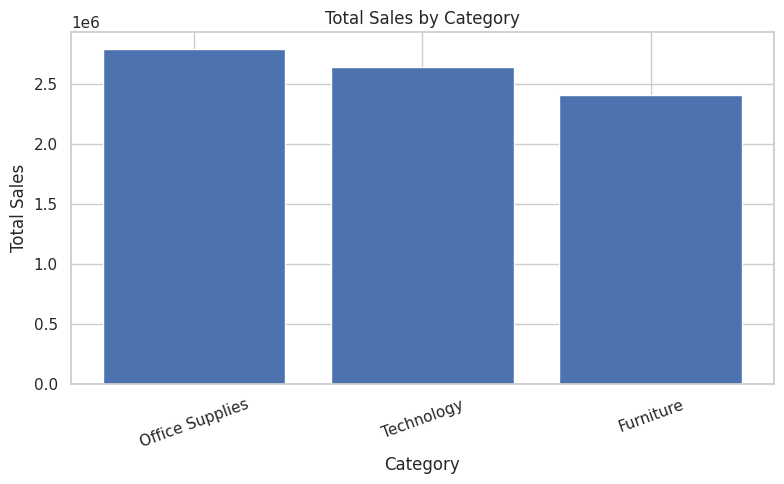

In [31]:
import matplotlib.pyplot as plt

# ============================================
# SALES BY CATEGORY
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis['Total_Sales']
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

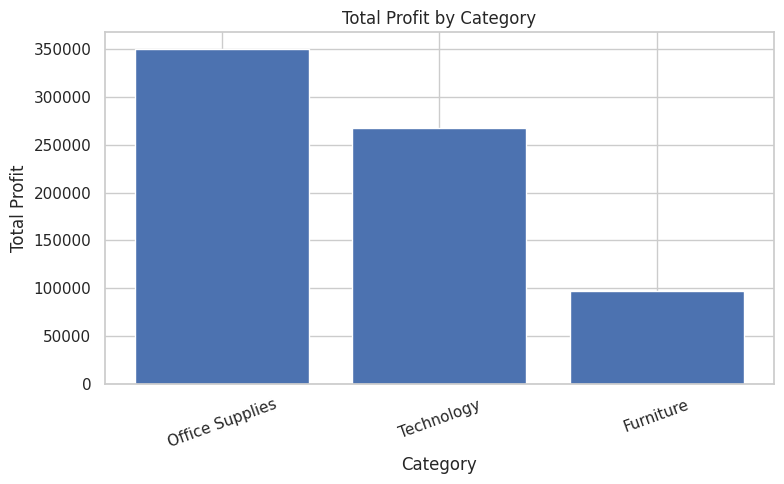

In [32]:
# ============================================
# PROFIT BY CATEGORY
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis['Total_Profit']
)

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

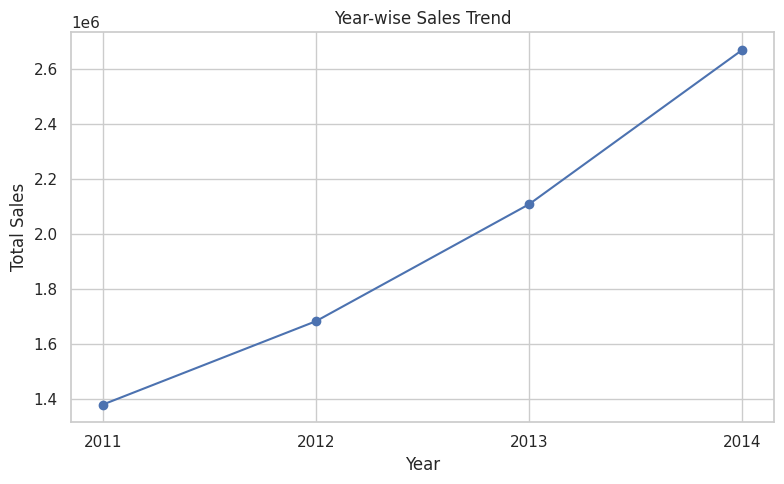

In [33]:
# ============================================
# YEAR-WISE SALES TREND
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    year_analysis.index,
    year_analysis['Total_Sales'],
    marker='o'
)

plt.title('Year-wise Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(year_analysis.index)
plt.grid(True)
plt.tight_layout()
plt.show()

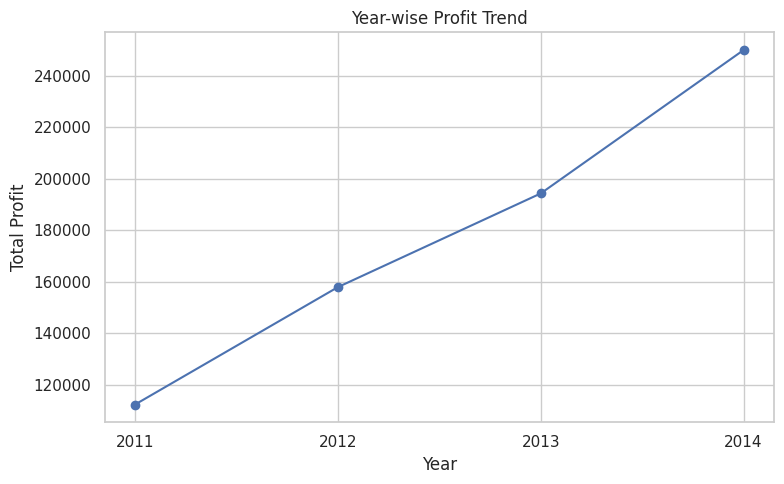

In [34]:
# ============================================
# YEAR-WISE PROFIT TREND
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    year_analysis.index,
    year_analysis['Total_Profit'],
    marker='o'
)

plt.title('Year-wise Profit Trend')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.xticks(year_analysis.index)
plt.grid(True)
plt.tight_layout()
plt.show()

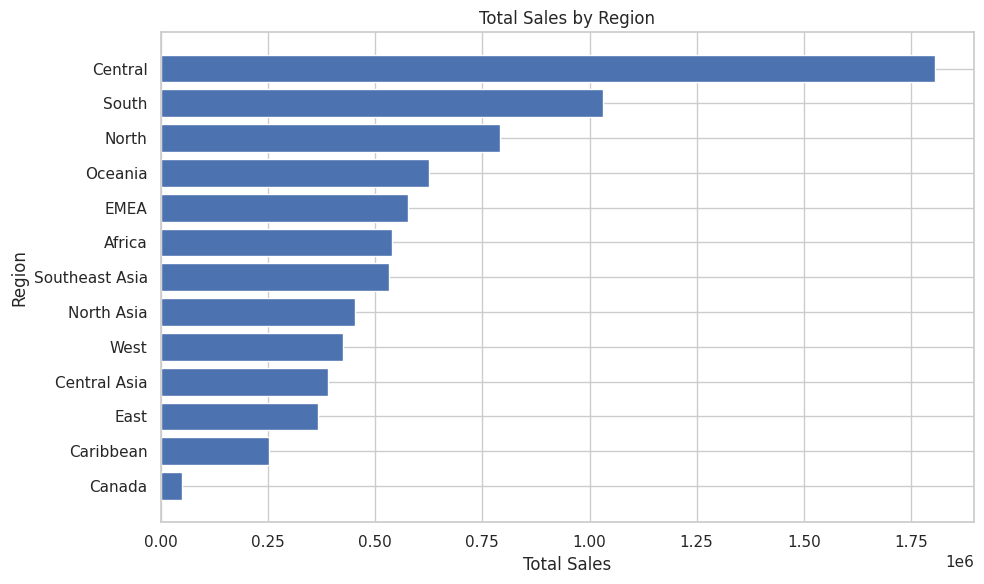

In [35]:
# ============================================
# SALES BY REGION
# ============================================

region_sales = region_analysis.sort_values(
    'Total_Sales',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    region_sales.index,
    region_sales['Total_Sales']
)

plt.title('Total Sales by Region')
plt.xlabel('Total Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

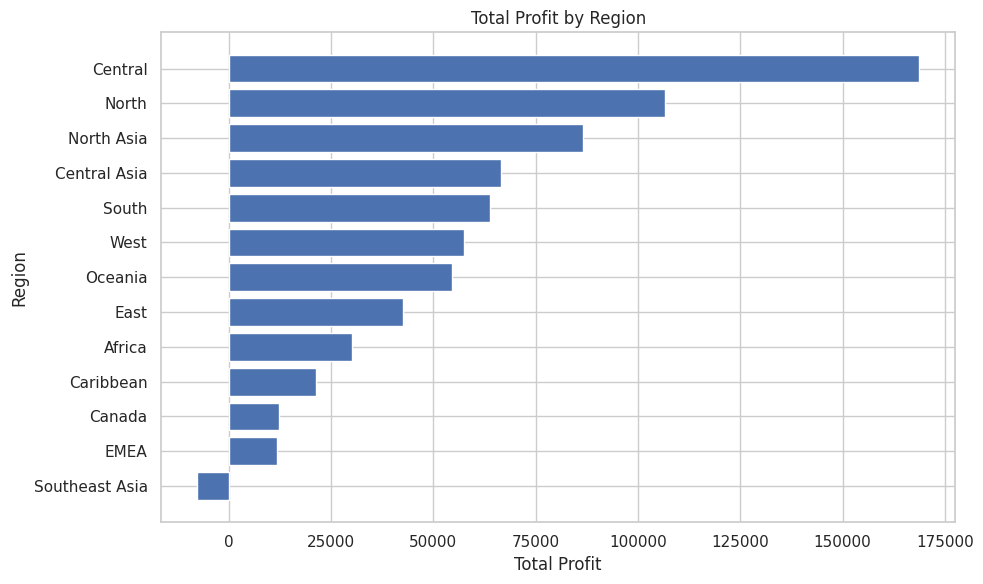

In [36]:
region_profit = region_analysis.sort_values('Total_Profit', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(region_profit.index, region_profit['Total_Profit'])

plt.title('Total Profit by Region')
plt.xlabel('Total Profit')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

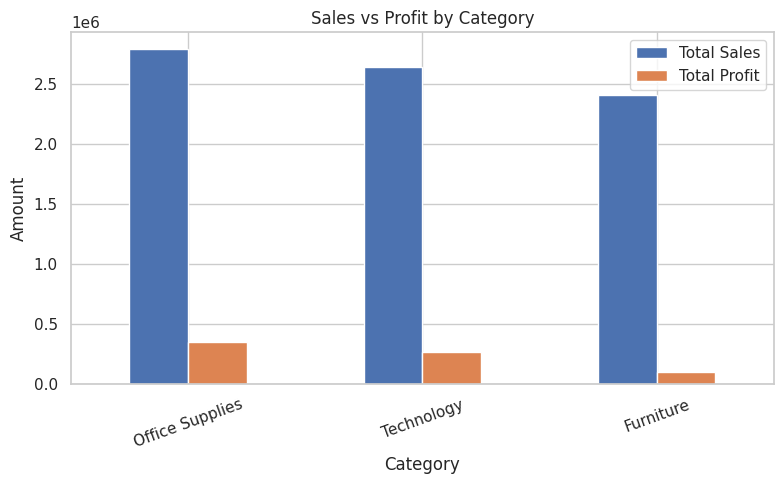

In [37]:
category_comparison = category_analysis[['Total_Sales', 'Total_Profit']]

category_comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=20)
plt.legend(['Total Sales', 'Total Profit'])

plt.tight_layout()
plt.show()

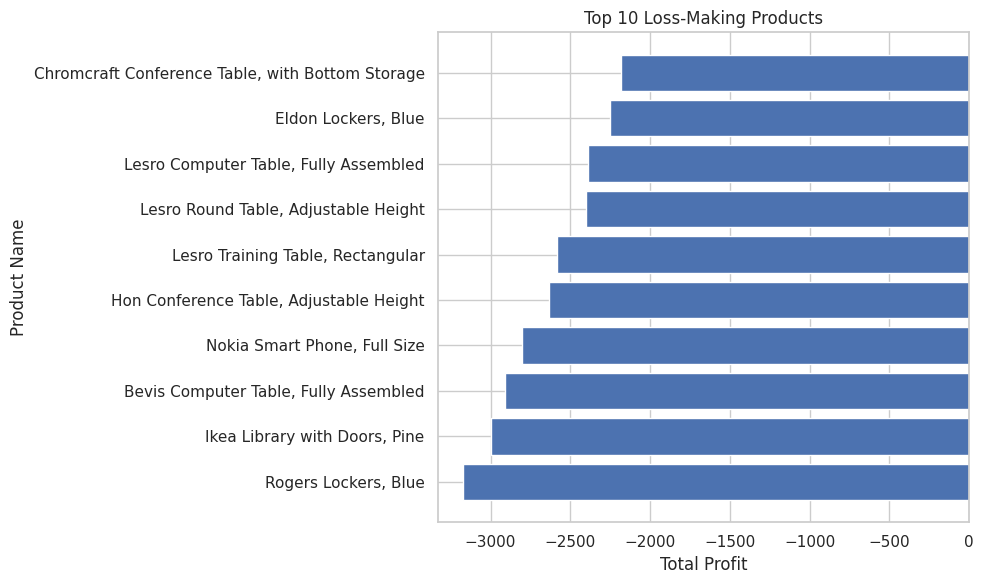

In [38]:
top_loss_products = (
    df_clean.groupby('product_name')
    .agg(
        Total_Sales=('sales', 'sum'),
        Total_Profit=('profit', 'sum')
    )
    .sort_values('Total_Profit', ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_loss_products.index,
    top_loss_products['Total_Profit']
)

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

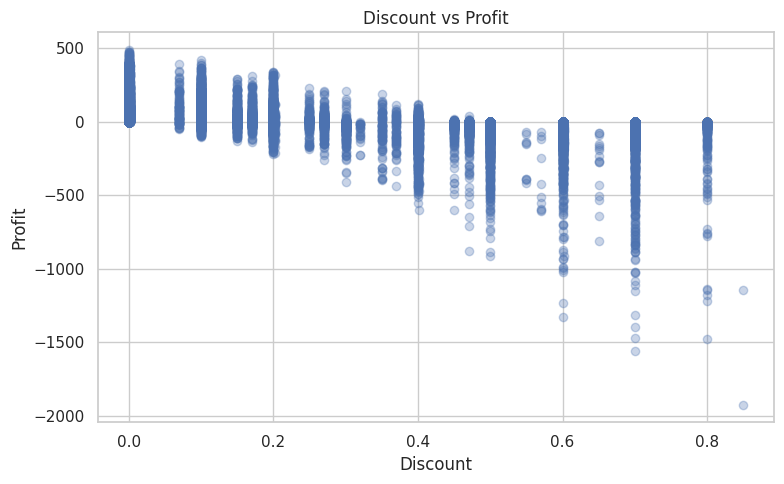

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean['discount'],
    df_clean['profit'],
    alpha=0.3
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
total_sales = df_clean['sales'].sum()
total_profit = df_clean['profit'].sum()
total_quantity = df_clean['quantity'].sum()
total_orders = df_clean['order_id'].nunique()
total_customers = df_clean['customer_name'].nunique()
profit_margin = (total_profit / total_sales) * 100
average_shipping_days = df_clean['shipping_days'].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Shipping Days:", round(average_shipping_days, 2))

Total Sales: 7835128.0
Total Profit: 714730.17
Total Quantity: 163043
Total Orders: 24386
Total Customers: 795
Profit Margin: 9.12 %
Average Shipping Days: 3.97


In [46]:
selected_category = 'Office Supplies'

filtered_data = df_clean[
    df_clean['category'] == selected_category
]

print("Selected Category:", selected_category)
print("Total Sales:", round(filtered_data['sales'].sum(), 2))
print("Total Profit:", round(filtered_data['profit'].sum(), 2))
print("Total Quantity:", filtered_data['quantity'].sum())
print("Total Orders:", filtered_data['order_id'].nunique())

Selected Category: Office Supplies
Total Sales: 2790258.0
Total Profit: 350107.32
Total Quantity: 105104
Total Orders: 18806


In [49]:
selected_region = 'EMEA'

filtered_region = df_clean[
    df_clean['region'] == selected_region
]

print("Selected Region:", selected_region)
print("Total Sales:", round(filtered_region['sales'].sum(), 2))
print("Total Profit:", round(filtered_region['profit'].sum(), 2))
print("Total Quantity:", filtered_region['quantity'].sum())
print("Total Orders:", filtered_region['order_id'].nunique())

Selected Region: EMEA
Total Sales: 575562.0
Total Profit: 11810.26
Total Quantity: 10695
Total Orders: 2435


In [53]:
selected_year = 2013

filtered_year = df_clean[
    df_clean['year'] == selected_year
]

print("Selected Year:", selected_year)
print("Total Sales:", round(filtered_year['sales'].sum(), 2))
print("Total Profit:", round(filtered_year['profit'].sum(), 2))
print("Total Quantity:", filtered_year['quantity'].sum())
print("Total Orders:", filtered_year['order_id'].nunique())

Selected Year: 2013
Total Sales: 2107021.0
Total Profit: 194353.16
Total Quantity: 44041
Total Orders: 6549


In [54]:
print("========== GLOBAL SUPERSTORE ANALYSIS ==========")

print("Total Sales:", round(df_clean['sales'].sum(), 2))
print("Total Profit:", round(df_clean['profit'].sum(), 2))
print("Total Orders:", df_clean['order_id'].nunique())
print("Total Customers:", df_clean['customer_name'].nunique())
print("Total Quantity:", df_clean['quantity'].sum())
print("Profit Margin:", round(
    (df_clean['profit'].sum() / df_clean['sales'].sum()) * 100, 2
), "%")
print("Average Shipping Days:", round(
    df_clean['shipping_days'].mean(), 2
))

print("\n========== KEY INSIGHTS ==========")

best_category = category_analysis['Total_Sales'].idxmax()
best_year = year_analysis['Total_Sales'].idxmax()
loss_region = region_analysis['Total_Profit'].idxmin()

print("Highest Sales Category:", best_category)
print("Highest Sales Year:", best_year)
print("Lowest Profit Region:", loss_region)

========== GLOBAL SUPERSTORE ANALYSIS ==========
Total Sales: 7835128.0
Total Profit: 714730.17
Total Orders: 24386
Total Customers: 795
Total Quantity: 163043
Profit Margin: 9.12 %
Average Shipping Days: 3.97

========== KEY INSIGHTS ==========
Highest Sales Category: Office Supplies
Highest Sales Year: 2014
Lowest Profit Region: Southeast Asia
